# PML universal settings & dataset preparation

This notebook finds robust PML settings for a 501×501 physical grid that work across ω = [20, 40, 80, 160],
and prepares utilities for direct solves and an iterative-refinement workflow suitable for dataset generation.

Goals:
- Inspect σ profiles and σ_max/ω to ensure PML strength is appropriate.
- Provide direct solver + iterative refinement helpers (k=0 initial RHS solve, k≥1 residual solves).
- Provide a reproducible `generate_sample(...)` that returns `f_phys`, `u_phys`, and intermediate residual solves for dataset labeling.

In [13]:
# Minimal imports (uses project code where helpful)
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import time

from core.resolution import grid_fixed_n_with_pml_extension
from core.grid import embed_in_extended, extract_physical
from core.config import PMLConfig, HelmholtzConfig
from core.medium import build_medium
from core.cases import make_default_cases
from operators.pml import build_pml_profiles, choose_pml_config, sigma_max_from_reflection
from operators.assemble import assemble_helmholtz_matrix
import scipy.sparse.linalg as spla

print('imports ok')


imports ok


In [14]:
# --- baseline grid + PML policy ---
n_phys = 501
lx = ly = 1.0
PPW = 10.0  # points per wavelength target used by grid helper (keeps consistent resolution)
OMEGAS = [20.0, 40.0, 80.0, 160.0]
# chooser anchors (you can tune these later)
NPML_REF = 40
ETA_REF = 6.0
PML_POWER = 2
PML_N_WAVES = 4.0  # baseline; we'll try larger values if needed
C_MIN = 1.0
print('baseline settings')

baseline settings


## Helpers: grid, sigma diagnostics, sources, embedding

In [15]:
def build_extended(n_phys, npml, lx=1.0, ly=1.0):
    # Use repo helper that fixes physical grid size and adds PML collar
    ext = grid_fixed_n_with_pml_extension(n_phys=n_phys, lx=lx, ly=ly, npml=npml)
    return ext  # has .grid_phys, .grid_ext, .core_slices

def compute_sigma_info(grid_ext, pml_cfg, omega):
    # build_pml_profiles expects HelmholtzConfig; returns 1D sig arrays and stretch factors
    cfg = HelmholtzConfig(omega=float(omega), grid=grid_ext, pml=pml_cfg)
    sig_x, sig_y, sx, sy = build_pml_profiles(cfg)
    SX, SY = np.meshgrid(sig_x, sig_y, indexing='ij')
    sigma2d = SX + SY
    sigma_max = float(max(sig_x.max(), sig_y.max()))
    return dict(sig_x=sig_x, sig_y=sig_y, sigma2d=sigma2d, sigma_max=sigma_max, sx=sx, sy=sy)

def plot_sigma(grid_ext, sigma_info):
    sx = sigma_info['sig_x']
    sy = sigma_info['sig_y']
    sigma2d = sigma_info['sigma2d']
    x_ext = np.linspace(grid_ext.x_min, grid_ext.x_min + grid_ext.lx, grid_ext.nx)
    y_ext = np.linspace(grid_ext.y_min, grid_ext.y_min + grid_ext.ly, grid_ext.ny)
    plt.figure(figsize=(6,5))
    plt.imshow(sigma2d.T, origin='lower', extent=(x_ext[0], x_ext[-1], y_ext[0], y_ext[-1]))
    plt.colorbar(label='sigma (1/sec)')
    plt.title('sigma map (PML)')
    plt.show()
    plt.figure(); plt.plot(x_ext, np.pad(sx, (0, grid_ext.nx - sx.size), 'edge')[:grid_ext.nx], label='sigma_x');
    plt.plot(y_ext, np.pad(sy, (0, grid_ext.ny - sy.size), 'edge')[:grid_ext.ny], label='sigma_y');
    plt.legend(); plt.title('1D sigma profiles'); plt.show()

def point_source_phys(n, x_frac=0.5, y_frac=0.5, amp=1.0):
    f = np.zeros((n, n), dtype=np.complex128)
    ix = int(np.round((n-1) * x_frac))
    iy = int(np.round((n-1) * y_frac))
    f[ix, iy] = amp
    return f

## Direct solve + iterative refinement helpers

We implement: `solve_direct(cfg, c_ext, f_ext)` → returns `u_ext` and residual;
and `iterative_refinement(cfg, c_ext, f_ext, niter)` which records `u` after each correction (k=0 initial).

In [16]:
def solve_direct(cfg, c_ext, f_ext):
    # assemble and solve using repo assembler (handles PML)
    A = assemble_helmholtz_matrix(cfg, c_ext)
    b = f_ext.reshape(-1)
    t0 = time.perf_counter()
    u_vec = spla.spsolve(A, b)
    tsolve = time.perf_counter() - t0
    u_ext = u_vec.reshape(cfg.grid.nx, cfg.grid.ny)
    r = b - A @ u_vec
    res_norm = float(np.linalg.norm(r) / (np.linalg.norm(b) + 1e-30))
    return dict(u_ext=u_ext, u_vec=u_vec, residual=r, res_norm=res_norm, tsolve=tsolve, A=A)

def iterative_refinement(cfg, c_ext, f_ext, niter=2):
    # niter >= 1: k=0 is initial RHS solve; for k>=1 solve for correction from residual
    out = []
    # initial solve (k=0)
    s0 = solve_direct(cfg, c_ext, f_ext)
    u_vec = s0['u_vec']
    out.append({'k':0, 'u_vec': u_vec.copy(), 'res_norm': s0['res_norm'], 'tsolve': s0['tsolve']})
    A = s0['A']
    b = f_ext.reshape(-1)
    for k in range(1, niter+1):
        r = b - A @ u_vec
        # solve A * delta = r (correction step)
        t0 = time.perf_counter()
        delta = spla.spsolve(A, r)
        tstep = time.perf_counter() - t0
        u_vec = u_vec + delta
        res_norm = float(np.linalg.norm(b - A @ u_vec) / (np.linalg.norm(b) + 1e-30))
        out.append({'k':k, 'u_vec': u_vec.copy(), 'res_norm': res_norm, 'tsolve': tstep})
    return out

## Sample generation function for datasets

`generate_sample` will: build extended grid for given `omega` and chosen `npml/eta`, assemble medium `c`, embed RHS, run iterative refinement and return cropped physical outputs plus metadata.

In [17]:
def generate_sample(omega, ppw, npml=None, eta=None, n_refine=1, sources=None, case_name='const'):
    # choose PML parameters if not provided
    if npml is None:
        npml = int(max(1, np.ceil(PML_N_WAVES * ppw)))
    if eta is None:
        # anchor to ETA_REF/NPML_REF policy
        eta = float(np.clip(ETA_REF * (NPML_REF / max(int(npml),1)), 2.0, 20.0))

    # build extended grid
    ext = grid_fixed_n_with_pml_extension(n_phys=n_phys, lx=lx, ly=ly, npml=int(npml))
    gext = ext.grid_ext
    gphys = ext.grid_phys
    si, sj = ext.core_slices

    # build pml config and helmholtz cfg
    pml_cfg = PMLConfig(thickness=int(npml), strength=float(eta), power=float(PML_POWER))
    cfg = HelmholtzConfig(omega=float(omega), grid=gext, pml=pml_cfg, ppw_target=float(ppw))

    # case + medium: build X, Y grids directly
    cases = make_default_cases()
    case = cases.get(case_name, list(cases.values())[0])
    # build X, Y using numpy meshgrid (ij indexing matches assembler)
    x = np.linspace(gext.x_min, gext.x_min + gext.lx, gext.nx)
    y = np.linspace(gext.y_min, gext.y_min + gext.ly, gext.ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    c_ext = build_medium(cfg=cfg, case=case, X=X, Y=Y)

    # build RHS on physical grid and embed
    if sources is None:
        f_phys = point_source_phys(n=gphys.nx, x_frac=0.5, y_frac=0.5, amp=1.0)
    else:
        # sources: list of dict with x,y in [0,1], amp, phase
        f_phys = np.zeros((gphys.nx, gphys.ny), dtype=np.complex128)
        x_coords, y_coords = np.linspace(gphys.x_min, gphys.x_min+gphys.lx, gphys.nx), np.linspace(gphys.y_min, gphys.y_min+gphys.ly, gphys.ny)
        for s in sources:
            ix = int(np.argmin(np.abs(x_coords - s['x'])))
            iy = int(np.argmin(np.abs(y_coords - s['y'])))
            f_phys[ix, iy] += s.get('amp', 1.0) * np.exp(1j * s.get('phase', 0.0))

    f_ext = np.zeros((gext.nx, gext.ny), dtype=np.complex128)
    f_ext[si, sj] = f_phys

    # iterative refinement solves (k=0 initial, k>=1 corrections)
    solves = iterative_refinement(cfg, c_ext, f_ext, niter=n_refine)

    # extract final solution and intermediate physical crops
    u_vec_final = solves[-1]['u_vec']
    u_ext_final = u_vec_final.reshape(gext.nx, gext.ny)
    u_phys_final = extract_physical(u_ext_final, (si, sj))

    # build metadata and packaged outputs
    meta = {
        'omega': float(omega), 'ppw': float(ppw), 'npml': int(npml), 'eta': float(eta), 'pml_power': float(PML_POWER),
        'solve_info': [{'k': s['k'], 'res_norm': float(s['res_norm']), 'tsolve': float(s['tsolve'])} for s in solves],
        'grid_phys': {'nx': int(gphys.nx), 'ny': int(gphys.ny), 'hx': float(gphys.hx), 'hy': float(gphys.hy)}
    }
    return dict(f_phys=f_phys, u_phys=u_phys_final, meta=meta, solves=solves)


## Demo: diagnose σ_max/ω and run one sample for each ω

This runs lightweight diagnostics (single solves) to inspect σ_max/ω and boundary behaviour.

In [18]:
def boundary_ratio(u, band=8):
    """Compute mean |u| on boundary band vs interior.
    
    Returns (br_mean, br_max): ratio of boundary to interior amplitudes.
    """
    A = np.abs(u)
    nx, ny = A.shape
    b = int(band)
    if nx <= 2*b or ny <= 2*b:
        interior = A
    else:
        interior = A[b:-b, b:-b]
    mask = np.zeros_like(A, dtype=bool)
    mask[:b,:] = True; mask[-b:,:] = True; mask[:,:b] = True; mask[:,-b:] = True
    boundary = A[mask]
    br_mean = float(boundary.mean() / (interior.mean() + 1e-30))
    br_max = float(boundary.max() / (interior.max() + 1e-30))
    return br_mean, br_max


omega=    20  sigma_max=1.814e+02  sigma_max/omega=9.068e+00


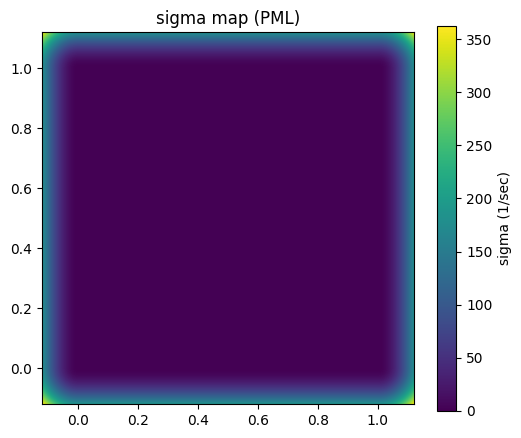

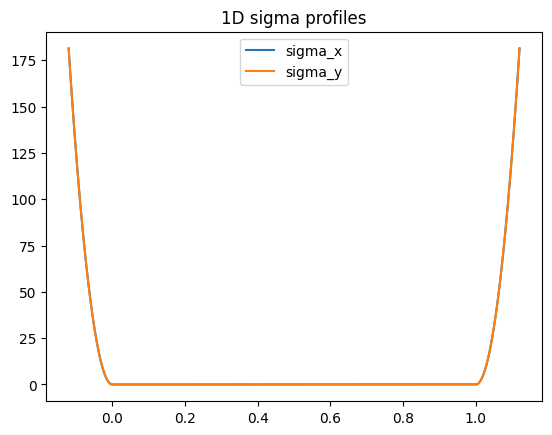

omega=    40  sigma_max=1.814e+02  sigma_max/omega=4.534e+00
omega=    80  sigma_max=1.814e+02  sigma_max/omega=2.267e+00
omega=   160  sigma_max=1.814e+02  sigma_max/omega=1.133e+00
omega=    20  br_mean=6.057e-01  br_max=9.894e-02  res0=3.183e-14
omega=    40  br_mean=7.291e-01  br_max=7.582e-02  res0=4.816e-14
omega=    80  br_mean=7.462e-01  br_max=5.172e-02  res0=5.996e-14
omega=   160  br_mean=7.441e-01  br_max=4.325e-02  res0=5.739e-14


In [19]:
# quick diagnostics: build ext grid with candidate npml and inspect sigma ratios
candidate_npml = 60
candidate_eta = ETA_REF
for w in OMEGAS:
    ext = grid_fixed_n_with_pml_extension(n_phys=n_phys, lx=lx, ly=ly, npml=candidate_npml)
    gext = ext.grid_ext
    pml_cfg = PMLConfig(thickness=candidate_npml, strength=candidate_eta, power=PML_POWER)
    info = compute_sigma_info(gext, pml_cfg, w)
    print(f'omega={w:6g}  sigma_max={info["sigma_max"]:.3e}  sigma_max/omega={info["sigma_max"]/float(w):.3e}')
    # optional quick plot for first omega only
    if w == OMEGAS[0]:
        plot_sigma(gext, info)

# run one sample (iterate once) for each omega and report boundary ratio
for w in OMEGAS:
    out = generate_sample(omega=w, ppw=PPW, npml=candidate_npml, eta=candidate_eta, n_refine=1)
    u = out['u_phys']
    br_mean, br_max = boundary_ratio(u, band=8)
    res0 = out['meta']['solve_info'][0]['res_norm']
    print(f'omega={w:6g}  br_mean={br_mean:.3e}  br_max={br_max:.3e}  res0={res0:.3e}')


## Save helper (save single sample as compressed npz)

In [20]:
def save_sample_npz(path: Path, f_phys, u_phys, meta):
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, f_real=np.real(f_phys).astype(np.float32), f_imag=np.imag(f_phys).astype(np.float32),
                        u_real=np.real(u_phys).astype(np.float32), u_imag=np.imag(u_phys).astype(np.float32),
                        meta_json=np.array([json.dumps(meta)], dtype=object))
    print('wrote', path)

# Example: save one sample for omega=20
example = generate_sample(omega=20.0, ppw=PPW, npml=60, eta=ETA_REF, n_refine=1)
save_sample_npz(Path('sample_omega20.npz'), example['f_phys'], example['u_phys'], example['meta'])

wrote sample_omega20.npz


## Validation: systematic PML parameter sweep

Sweep across candidate npml and eta values to find universal settings that minimize boundary ratio (br_mean) for all four omegas.
This identifies the most robust PML configuration.

In [21]:
# Systematic sweep over npml and eta to find universal optimal settings
import pandas as pd

# candidate values
npml_values = [40, 50, 60, 70, 80, 100]
eta_values = [4.0, 6.0, 8.0, 10.0, 12.0]

results = []

print("Running PML parameter sweep...")
print("-" * 80)
print(f"Total configurations: {len(npml_values) * len(eta_values)} | Total omegas: {len(OMEGAS)}")
print("-" * 80)

sweep_start = time.perf_counter()

for npml in npml_values:
    npml_start = time.perf_counter()
    for eta in eta_values:
        # Compute sigma_max/omega for diagnostics
        ext = grid_fixed_n_with_pml_extension(n_phys=n_phys, lx=lx, ly=ly, npml=npml)
        gext = ext.grid_ext
        pml_cfg = PMLConfig(thickness=npml, strength=eta, power=PML_POWER)
        
        # Track results for each omega
        br_means = []
        sigma_ratios = []
        
        for omega in OMEGAS:
            info = compute_sigma_info(gext, pml_cfg, omega)
            sigma_ratio = info['sigma_max'] / float(omega)
            sigma_ratios.append(sigma_ratio)
            
            # Generate sample and compute boundary ratio
            out = generate_sample(omega=omega, ppw=PPW, npml=npml, eta=eta, n_refine=1)
            u = out['u_phys']
            br_mean, _ = boundary_ratio(u, band=8)
            br_means.append(br_mean)
        
        # Aggregate metrics across all omegas
        br_mean_avg = np.mean(br_means)
        br_mean_max = np.max(br_means)
        sigma_ratio_avg = np.mean(sigma_ratios)
        
        results.append({
            'npml': npml,
            'eta': eta,
            'br_mean_avg': br_mean_avg,
            'br_mean_max': br_mean_max,
            'sigma_ratio_avg': sigma_ratio_avg,
            'br_20': br_means[0],
            'br_40': br_means[1],
            'br_80': br_means[2],
            'br_160': br_means[3]
        })
        print(f"npml={npml:3d}  eta={eta:4.1f}  br_mean_avg={br_mean_avg:.3e}  br_mean_max={br_mean_max:.3e}  sigma/ω={sigma_ratio_avg:.3e}")
    npml_elapsed = time.perf_counter() - npml_start
    configs_for_npml = len(eta_values)
    print(f"  → npml={npml} completed {configs_for_npml} eta configs in {npml_elapsed:.2f}s")

sweep_elapsed = time.perf_counter() - sweep_start
print("-" * 80)
print(f"✓ Total sweep time: {sweep_elapsed:.2f}s ({sweep_elapsed/60:.1f} min)")
print()

# Convert to DataFrame for analysis
df_results = pd.DataFrame(results)

# Find best configurations by different metrics
print("=" * 80)
print("SUMMARY: Top 5 configurations by br_mean_avg (lower is better)")
print("=" * 80)
best_by_avg = df_results.nsmallest(5, 'br_mean_avg')[['npml', 'eta', 'br_mean_avg', 'br_mean_max', 'sigma_ratio_avg']]
print(best_by_avg.to_string(index=False))
print()

print("=" * 80)
print("SUMMARY: Top 5 configurations by br_mean_max (lower is better for worst case)")
print("=" * 80)
best_by_max = df_results.nsmallest(5, 'br_mean_max')[['npml', 'eta', 'br_mean_avg', 'br_mean_max', 'sigma_ratio_avg']]
print(best_by_max.to_string(index=False))
print()

# Recommendation
optimal_idx = df_results['br_mean_avg'].idxmin()
optimal_row = df_results.loc[optimal_idx]
print("=" * 80)
print(f"RECOMMENDED UNIVERSAL PML SETTINGS (based on lowest avg br_mean):")
print(f"  npml = {int(optimal_row['npml'])}")
print(f"  eta = {optimal_row['eta']:.1f}")
print(f"  Expected avg br_mean = {optimal_row['br_mean_avg']:.3e}")
print(f"  Expected worst-case br_mean = {optimal_row['br_mean_max']:.3e}")
print("=" * 80)


Running PML parameter sweep...
--------------------------------------------------------------------------------
Total configurations: 30 | Total omegas: 4
--------------------------------------------------------------------------------
npml= 40  eta= 4.0  br_mean_avg=7.050e-01  br_mean_max=7.603e-01  sigma/ω=4.352e+00
npml= 40  eta= 6.0  br_mean_avg=7.130e-01  br_mean_max=7.668e-01  sigma/ω=6.376e+00
npml= 40  eta= 8.0  br_mean_avg=7.201e-01  br_mean_max=8.011e-01  sigma/ω=8.400e+00
npml= 40  eta=10.0  br_mean_avg=7.253e-01  br_mean_max=8.349e-01  sigma/ω=1.042e+01
npml= 40  eta=12.0  br_mean_avg=7.294e-01  br_mean_max=8.601e-01  sigma/ω=1.245e+01
  → npml=40 completed 5 eta configs in 17340.03s
npml= 50  eta= 4.0  br_mean_avg=6.999e-01  br_mean_max=7.444e-01  sigma/ω=3.482e+00
npml= 50  eta= 6.0  br_mean_avg=7.051e-01  br_mean_max=7.506e-01  sigma/ω=5.101e+00
npml= 50  eta= 8.0  br_mean_avg=7.089e-01  br_mean_max=7.567e-01  sigma/ω=6.720e+00
npml= 50  eta=10.0  br_mean_avg=7.124e-01  

## Dataset generation: single-source RHS

Generate training pairs with one randomized point source (location and amplitude in [1, 2]).


In [22]:
# Use optimal settings from validation (update these after running validation cell)
OPTIMAL_NPML = 60  # Replace with value from validation
OPTIMAL_ETA = 6.0  # Replace with value from validation

# Helper: format time nicely
def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.2f}s"
    elif seconds < 3600:
        return f"{seconds/60:.1f}min"
    else:
        return f"{seconds/3600:.1f}h"

def generate_single_source_dataset(output_dir, num_samples, omegas=None, npml=None, eta=None, n_refine=1, seed=None):
    """
    Generate dataset with single randomized point source.
    
    Args:
        output_dir: Path to save dataset
        num_samples: Number of samples per omega
        omegas: List of frequencies (default: OMEGAS)
        npml: PML thickness (default: OPTIMAL_NPML)
        eta: PML strength (default: OPTIMAL_ETA)
        n_refine: Number of iterative refinement iterations
        seed: Random seed for reproducibility
    
    Returns:
        Dictionary with counts and metadata
    """
    if omegas is None:
        omegas = OMEGAS
    if npml is None:
        npml = OPTIMAL_NPML
    if eta is None:
        eta = OPTIMAL_ETA
    
    if seed is not None:
        np.random.seed(seed)
    
    output_path = Path(output_dir) / "single_source"
    output_path.mkdir(parents=True, exist_ok=True)
    
    metadata = {
        'type': 'single_source',
        'num_samples': num_samples,
        'omegas': list(omegas),
        'npml': npml,
        'eta': eta,
        'n_refine': n_refine,
        'samples': {},
        'timing': {}
    }
    
    total_count = 0
    dataset_start = time.perf_counter()
    
    for omega in omegas:
        omega_dir = output_path / f"omega_{omega:.0f}"
        omega_dir.mkdir(parents=True, exist_ok=True)
        omega_start = time.perf_counter()
        
        for i in range(num_samples):
            # Randomize source location (in [0, 1] domain fractions)
            x_frac = np.random.uniform(0.2, 0.8)  # Avoid extreme corners
            y_frac = np.random.uniform(0.2, 0.8)
            amp = np.random.uniform(1.0, 2.0)
            
            # Generate sample
            sources = [{'x': x_frac, 'y': y_frac, 'amp': amp, 'phase': 0.0}]
            out = generate_sample(
                omega=omega, 
                ppw=PPW, 
                npml=npml, 
                eta=eta, 
                n_refine=n_refine, 
                sources=sources
            )
            
            # Build metadata
            sample_meta = {
                'sample_idx': i,
                'source_x': x_frac,
                'source_y': y_frac,
                'source_amp': amp,
                **out['meta']
            }
            
            # Save as npz
            filename = f"sample_{i:06d}.npz"
            filepath = omega_dir / filename
            save_sample_npz(filepath, out['f_phys'], out['u_phys'], sample_meta)
            
            metadata['samples'][f'omega_{omega:.0f}_sample_{i}'] = {
                'file': str(filepath),
                'source_x': float(x_frac),
                'source_y': float(y_frac),
                'source_amp': float(amp)
            }
            
            total_count += 1
            if (i + 1) % 10 == 0:
                elapsed_omega = time.perf_counter() - omega_start
                rate = (i + 1) / elapsed_omega
                remaining = (num_samples - (i+1)) / rate if rate > 0 else 0
                print(f"  omega={omega:.0f}: {i+1:3d}/{num_samples} | {format_time(elapsed_omega)} | ~{format_time(remaining)} remaining")
        
        omega_elapsed = time.perf_counter() - omega_start
        metadata['timing'][f'omega_{omega:.0f}'] = omega_elapsed
    
    # Save metadata
    total_elapsed = time.perf_counter() - dataset_start
    metadata['timing']['total'] = total_elapsed
    metadata['timing']['per_sample_avg'] = total_elapsed / total_count if total_count > 0 else 0
    
    metadata_path = output_path / "metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"\n" + "="*80)
    print(f"✓ Single-source dataset generation complete!")
    print(f"  Total samples: {total_count}")
    print(f"  Total time: {format_time(total_elapsed)}")
    print(f"  Avg time per sample: {metadata['timing']['per_sample_avg']:.2f}s")
    print(f"  Metadata: {metadata_path}")
    print(f"="*80)
    
    return metadata

# Example usage (uncomment to run):
# metadata_single = generate_single_source_dataset(
#     output_dir='data/single_source_dataset',
#     num_samples=20,
#     npml=OPTIMAL_NPML,
#     eta=OPTIMAL_ETA,
#     seed=42
# )

## Dataset generation: multi-source RHS

Generate training pairs with randomized number of point sources (1-5), randomized locations and amplitudes.


In [23]:
def generate_multi_source_dataset(output_dir, num_samples, omegas=None, npml=None, eta=None, n_refine=1, seed=None):
    """
    Generate dataset with variable number of point sources (1-5 per sample).
    
    Args:
        output_dir: Path to save dataset
        num_samples: Number of samples per omega
        omegas: List of frequencies (default: OMEGAS)
        npml: PML thickness (default: OPTIMAL_NPML)
        eta: PML strength (default: OPTIMAL_ETA)
        n_refine: Number of iterative refinement iterations
        seed: Random seed for reproducibility
    
    Returns:
        Dictionary with counts and metadata
    """
    if omegas is None:
        omegas = OMEGAS
    if npml is None:
        npml = OPTIMAL_NPML
    if eta is None:
        eta = OPTIMAL_ETA
    
    if seed is not None:
        np.random.seed(seed)
    
    output_path = Path(output_dir) / "multi_source"
    output_path.mkdir(parents=True, exist_ok=True)
    
    metadata = {
        'type': 'multi_source',
        'num_samples': num_samples,
        'omegas': list(omegas),
        'npml': npml,
        'eta': eta,
        'n_refine': n_refine,
        'source_distribution': '1-5 sources per sample',
        'samples': {},
        'timing': {}
    }
    
    total_count = 0
    dataset_start = time.perf_counter()
    
    for omega in omegas:
        omega_dir = output_path / f"omega_{omega:.0f}"
        omega_dir.mkdir(parents=True, exist_ok=True)
        omega_start = time.perf_counter()
        
        for i in range(num_samples):
            # Randomize number of sources (1-5)
            num_sources = np.random.randint(1, 6)
            
            # Generate sources with randomized locations and amplitudes
            sources = []
            for j in range(num_sources):
                x_frac = np.random.uniform(0.15, 0.85)
                y_frac = np.random.uniform(0.15, 0.85)
                amp = np.random.uniform(1.0, 2.0)
                phase = np.random.uniform(0, 2*np.pi)
                sources.append({
                    'x': x_frac,
                    'y': y_frac,
                    'amp': amp,
                    'phase': phase
                })
            
            # Generate sample
            out = generate_sample(
                omega=omega, 
                ppw=PPW, 
                npml=npml, 
                eta=eta, 
                n_refine=n_refine, 
                sources=sources
            )
            
            # Build metadata with source information
            sample_meta = {
                'sample_idx': i,
                'num_sources': num_sources,
                'sources': sources,
                **out['meta']
            }
            
            # Save as npz
            filename = f"sample_{i:06d}.npz"
            filepath = omega_dir / filename
            save_sample_npz(filepath, out['f_phys'], out['u_phys'], sample_meta)
            
            metadata['samples'][f'omega_{omega:.0f}_sample_{i}'] = {
                'file': str(filepath),
                'num_sources': int(num_sources),
                'sources': [
                    {'x': float(s['x']), 'y': float(s['y']), 'amp': float(s['amp']), 'phase': float(s['phase'])}
                    for s in sources
                ]
            }
            
            total_count += 1
            if (i + 1) % 10 == 0:
                elapsed_omega = time.perf_counter() - omega_start
                rate = (i + 1) / elapsed_omega
                remaining = (num_samples - (i+1)) / rate if rate > 0 else 0
                print(f"  omega={omega:.0f}: {i+1:3d}/{num_samples} | {format_time(elapsed_omega)} | ~{format_time(remaining)} remaining")
        
        omega_elapsed = time.perf_counter() - omega_start
        metadata['timing'][f'omega_{omega:.0f}'] = omega_elapsed
    
    # Save metadata
    total_elapsed = time.perf_counter() - dataset_start
    metadata['timing']['total'] = total_elapsed
    metadata['timing']['per_sample_avg'] = total_elapsed / total_count if total_count > 0 else 0
    
    metadata_path = output_path / "metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"\n" + "="*80)
    print(f"✓ Multi-source dataset generation complete!")
    print(f"  Total samples: {total_count}")
    print(f"  Total time: {format_time(total_elapsed)}")
    print(f"  Avg time per sample: {metadata['timing']['per_sample_avg']:.2f}s")
    print(f"  Metadata: {metadata_path}")
    print(f"="*80)
    
    return metadata

# Example usage (uncomment to run):
# metadata_multi = generate_multi_source_dataset(
#     output_dir='data/multi_source_dataset',
#     num_samples=20,
#     npml=OPTIMAL_NPML,
#     eta=OPTIMAL_ETA,
#     seed=42
# )

## Quick dataset generation examples

Run these cells to generate your training datasets.


In [24]:
# Generate single-source dataset
# Update OPTIMAL_NPML and OPTIMAL_ETA from the validation cell results before running
print("\n" + "#" * 80)
print("# GENERATING SINGLE-SOURCE DATASET (1 source per sample)")
print("#" * 80)
metadata_single = generate_single_source_dataset(
    output_dir='data/single_source_dataset',
    num_samples=20,  # Modify as needed
    npml=OPTIMAL_NPML,
    eta=OPTIMAL_ETA,
    n_refine=1,
    seed=42
)


################################################################################
# GENERATING SINGLE-SOURCE DATASET (1 source per sample)
################################################################################
wrote data\single_source_dataset\single_source\omega_20\sample_000000.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000001.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000002.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000003.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000004.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000005.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000006.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000007.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000008.npz
wrote data\single_source_dataset\single_source\omega_20\sample_000009.npz
  omega=20:  10/20 | 28.0min | ~28.0min 

In [25]:
# Generate multi-source dataset
# Update OPTIMAL_NPML and OPTIMAL_ETA from the validation cell results before running
print("\n" + "#" * 80)
print("# GENERATING MULTI-SOURCE DATASET (1-5 sources per sample)")
print("#" * 80)
metadata_multi = generate_multi_source_dataset(
    output_dir='data/multi_source_dataset',
    num_samples=20,  # Modify as needed
    npml=OPTIMAL_NPML,
    eta=OPTIMAL_ETA,
    n_refine=1,
    seed=42
)


################################################################################
# GENERATING MULTI-SOURCE DATASET (1-5 sources per sample)
################################################################################
wrote data\multi_source_dataset\multi_source\omega_20\sample_000000.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000001.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000002.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000003.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000004.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000005.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000006.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000007.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000008.npz
wrote data\multi_source_dataset\multi_source\omega_20\sample_000009.npz
  omega=20:  10/20 | 42.6min | ~42.6min remaining
wrote da